In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

In [2]:
diabetes_df = load_diabetes(as_frame=True).frame

In [3]:
diabetes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [4]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [5]:
diabetes_df.duplicated().sum()

np.int64(0)

In [6]:
# split
X = diabetes_df.drop(columns=["target"])
y = diabetes_df["target"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [8]:
model_dtr = DecisionTreeRegressor()
model_dtr.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [9]:
y_test_pred = model_dtr.predict(X_test)
r2_test = r2_score(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

y_train_pred = model_dtr.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)

print("Testing:")
print("R2", r2_test)
print("MSE", mse_test)

print("Training:")
print("R2", r2_train)
print("MSE", mse_train)

Testing:
R2 -0.05070242153301141
MSE 5672.015037593985
Training:
R2 1.0
MSE 0.0


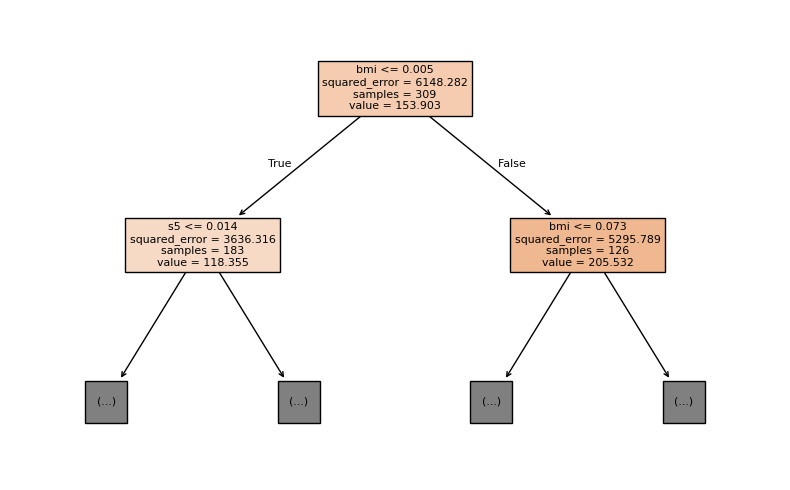

In [10]:
plt.figure(figsize=(8, 5))

plot_tree(
    model_dtr,
    feature_names=X.columns,
    filled=True,
    max_depth=1
)

plt.tight_layout()


In [11]:
# model training - pre pruning
model_dtr_cv = GridSearchCV(
    DecisionTreeRegressor(),
    {
        "max_depth" : np.arange(1, 20),
        "min_samples_split": np.arange(5, 50, 5),
        "min_samples_leaf": np.arange(5, 50, 5),
    },
    cv=5, 
)

model_dtr_cv.fit(X_train, y_train)

y_test_pred = model_dtr_cv.predict(X_test)
r2_test = r2_score(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

y_train_pred = model_dtr_cv.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)

print("Testing:")
print("R2", r2_test)
print("MSE", mse_test)

print("Training:")
print("R2", r2_train)
print("MSE", mse_train)


Testing:
R2 0.41825936898628335
MSE 3140.4149638057584
Training:
R2 0.5197309905297729
MSE 2952.829227404435


In [12]:
# Model training - with Linear Regression
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_test_pred = model_lr.predict(X_test)
r2_test = r2_score(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

y_train_pred = model_lr.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)

print("Testing:")
print("R2", r2_test)
print("MSE", mse_test)

print("Training:")
print("R2", r2_train)
print("MSE", mse_train)

Testing:
R2 0.4772897164322618
MSE 2821.7509810013103
Training:
R2 0.5244124363545944
MSE 2924.0463790726394


In [13]:
# Model training - with kNN Regressor
model_knn = KNeighborsRegressor()
model_knn.fit(X_train, y_train)

y_test_pred = model_knn.predict(X_test)
r2_test = r2_score(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

y_train_pred = model_knn.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)

print("Testing:")
print("R2", r2_test)
print("MSE", mse_test)

print("Training:")
print("R2", r2_train)
print("MSE", mse_train)

Testing:
R2 0.4031244536507893
MSE 3222.117894736842
Training:
R2 0.5726983872342755
MSE 2627.1707443365694


In [ ]:
# Model training - Random Forest Regressor
rfr_model = RandomForestRegressor(
    n_estimators=201,
    oob_score=True,
)

rfr_model.fit(X_train, y_train)



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:513: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y)


,n_estimators,201
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [16]:
y_test_pred = rfr_model.predict(X_test)
r2_test = r2_score(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

y_train_pred = model_knn.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)

print("Testing:")
print("R2", r2_test)
print("MSE", mse_test)

print("Training:")
print("R2", r2_train)
print("MSE", mse_train)

Testing:
R2 0.4646404825704077
MSE 2890.0354383396675
Training:
R2 0.5726983872342755
MSE 2627.1707443365694


In [18]:
# Model training - CV on Random Forest Regressor
rfr_cv_model = GridSearchCV(
    RandomForestRegressor(
        n_estimators=201,
        oob_score=True,
    ),
    {
        "max_depth" : np.arange(1, 20),
        "min_samples_split": np.arange(5, 50, 5),
    },
    cv=5,
)

rfr_cv_model.fit(X_train, y_train)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:513: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:513: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:513: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:513: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem,

,estimator,RandomForestR...ob_score=True)
,param_grid,"{'max_depth': array([ 1, 2... 18, 19]), 'min_samples_split': array([ 5, 10..., 35, 40, 45])}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,201


In [19]:
y_test_pred = rfr_cv_model.predict(X_test)
r2_test = r2_score(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

y_train_pred = model_knn.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)

print("Testing:")
print("R2", r2_test)
print("MSE", mse_test)

print("Training:")
print("R2", r2_train)
print("MSE", mse_train)

Testing:
R2 0.49496283314231904
MSE 2726.346057888693
Training:
R2 0.5726983872342755
MSE 2627.1707443365694
